In [1]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df_index = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_20240911.csv',index_col=0)
df_altref = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_alleleOnly_20240605.csv")
df_index = df_index.loc[df_altref['0']]
#df_index_promoter = df_index[df_index['gene']==1]
#df_index_promoter = df_index[abs(df_index['distance_to_tss'])<=10000]
#df_index_promoter = df_index[df_index['SNP_Function']=='Immune']
df_index2 = df_index.copy()
df_index2.index= df_altref['1']
df_index_altref = pd.concat([df_index,df_index2])
df_index_altref = df_index_altref.reset_index().drop_duplicates(subset='index').set_index('index')
GC_content = df_index_altref['GC_content']
GC_content=GC_content.loc[df_index_altref.index]

In [3]:
RNA = pd.read_csv("read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref.csv", index_col=0)
DNA = pd.read_csv("read_counts_R1R2/THP1Macrophage_DNA_matched_barcodes_reshaped_altref.csv", index_col=0)

In [4]:
RNA

,IFNB_THP1mac_ZC58_R_ALT_Barcode_1,IFNB_THP1mac_ZC58_R_ALT_Barcode_2,IFNB_THP1mac_ZC58_R_ALT_Barcode_3,IFNB_THP1mac_ZC58_R_ALT_Barcode_4,IFNB_THP1mac_ZC58_R_ALT_Barcode_5,IFNB_THP1mac_ZC58_R_ALT_Barcode_6,IFNB_THP1mac_ZC58_R_ALT_Barcode_7,IFNB_THP1mac_ZC58_R_ALT_Barcode_8,IFNB_THP1mac_ZC58_R_ALT_Barcode_9,IFNB_THP1mac_ZC58_R_ALT_Barcode_10,...,Naive_THP1mac_ZC91_R_ALT_Barcode_23,Naive_THP1mac_ZC91_R_ALT_Barcode_24,Naive_THP1mac_ZC91_R_ALT_Barcode_25,Naive_THP1mac_ZC91_R_ALT_Barcode_26,Naive_THP1mac_ZC91_R_ALT_Barcode_27,Naive_THP1mac_ZC91_R_ALT_Barcode_28,Naive_THP1mac_ZC91_R_ALT_Barcode_29,Naive_THP1mac_ZC91_R_ALT_Barcode_30,Naive_THP1mac_ZC91_R_ALT_Barcode_31,Naive_THP1mac_ZC91_R_ALT_Barcode_32
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,178.0,404.0,791.0,687.0,698.0,616.0,886.0,794.0,566.0,893.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,969.0,1023.0,406.0,736.0,668.0,683.0,1066.0,734.0,1015.0,1133.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,267.0,506.0,296.0,545.0,290.0,537.0,604.0,433.0,536.0,432.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,361.0,240.0,355.0,318.0,908.0,441.0,279.0,467.0,589.0,335.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,157.0,197.0,240.0,499.0,209.0,135.0,264.0,256.0,322.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ref:rs9281938:PEAKCENTER:chr6:32576282:T:TA:32576044:32576544:32576294,258.0,90.0,372.0,173.0,132.0,236.0,213.0,264.0,220.0,314.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ref:rs9304646:PEAKCENTER:chr19:44947151:T:A:44946977:44947477:44947227,344.0,461.0,718.0,482.0,678.0,367.0,403.0,529.0,335.0,479.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ref:rs9357546:PEAKCENTER:chr6:47549495:C:T:47549371:47549664:47549511,71.0,66.0,60.0,103.0,125.0,149.0,78.0,131.0,89.0,54.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ref:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,94.0,84.0,372.0,202.0,323.0,262.0,135.0,163.0,228.0,313.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


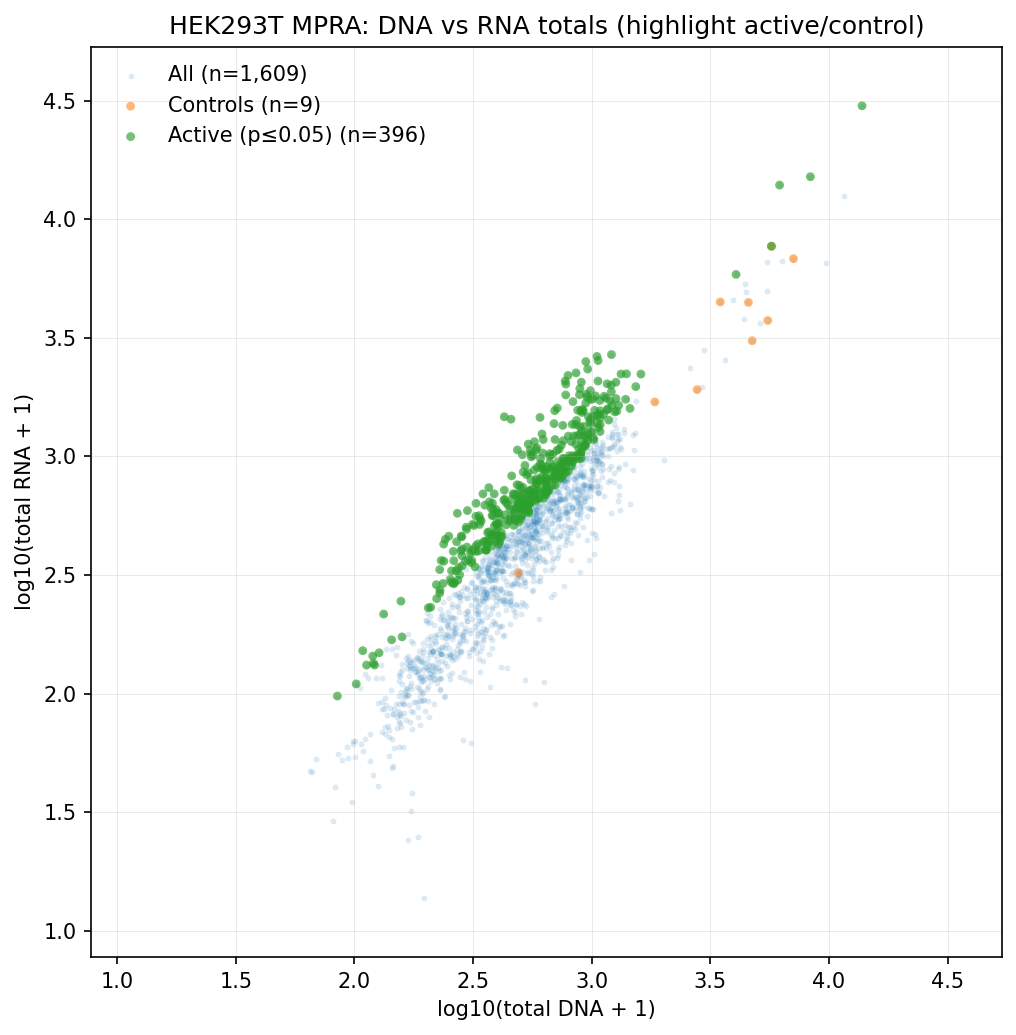

In [4]:
# %% [markdown]
# # DNA vs RNA total counts (log10) with active/control highlights

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# %%
dna_path = "../outputs/read_counts_R1R2/HEK293T_DNA_matched_barcodes_reshaped_altref_withcontrol_noSV40.csv"
rna_path = "../outputs/read_counts_R1R2/HEK293T_RNA_matched_barcodes_reshaped_altref_withcontrol_noSV40.csv"
mad_path = "../outputs/mpranalyze_results/20260120_MAD_HEK293T_withcontrol.csv"

special_id = "PanTissueControl.SV40_224bp_1xEnh_Promoter"

# %%
# Load and compute per-element total DNA/RNA (sum across barcode columns)
dna = pd.read_csv(dna_path, index_col=0).sum(axis=1)
rna = pd.read_csv(rna_path, index_col=0).sum(axis=1)
dna=dna/dna.sum()*1000000
rna=rna/rna.sum()*1000000
mad = pd.read_csv(mad_path, index_col=0)

threshold = 0.05
# %%
# Indices
active_index = mad.index[mad["pval.empirical"] <= threshold]
control_index = mad.index[mad["control"] == True]

# Make sure indices exist in dna/rna tables (avoid KeyError)
common = dna.index.intersection(rna.index)
active_index = common.intersection(active_index)
control_index = common.intersection(control_index)

# %%
# log transform (add pseudocount to avoid log(0))
x = np.log10(dna.loc[common] + 1)
y = np.log10(rna.loc[common] + 1)

xa = np.log10(dna.loc[active_index] + 1)
ya = np.log10(rna.loc[active_index] + 1)

xc = np.log10(dna.loc[control_index] + 1)
yc = np.log10(rna.loc[control_index] + 1)

# special point (if present)
has_special = special_id in common
if has_special:
    xs = float(np.log10(dna.loc[special_id] + 1))
    ys = float(np.log10(rna.loc[special_id] + 1))

# %%
# Plot
fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

# Background: all points
ax.scatter(x, y, s=8, alpha=0.15, linewidths=0, label=f"All (n={len(common):,})")

# Controls
ax.scatter(xc, yc, s=18, alpha=0.55, linewidths=0.2, edgecolors="none", label=f"Controls (n={len(control_index):,})")

# Active
ax.scatter(xa, ya, s=18, alpha=0.65, linewidths=0.2, edgecolors="none", label=f"Active (p≤{threshold}) (n={len(active_index):,})")

# Special point
if has_special:
    ax.scatter([xs], [ys], s=80, alpha=0.95, marker="*", label="SV40 ori element")

# Reference line y = x
xmin = float(min(x.min(), y.min()))
xmax = float(max(x.max(), y.max()))
pad = 0.25
lo = xmin - pad
hi = xmax + pad
#ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

# Labels / styling
ax.set_xlabel("log10(total DNA + 1)")
ax.set_ylabel("log10(total RNA + 1)")
ax.set_title("HEK293T MPRA: DNA vs RNA totals (highlight active/control)")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")

ax.grid(True, linewidth=0.4, alpha=0.3)
ax.legend(frameon=False, loc="best")

# Annotate special point nicely
if has_special:
    ax.annotate(
        special_id,
        xy=(xs, ys),
        xytext=(xs + 0.6, ys + 0.6),
        arrowprops=dict(arrowstyle="->", linewidth=0.8),
        fontsize=8,
    )

plt.tight_layout()
plt.show()



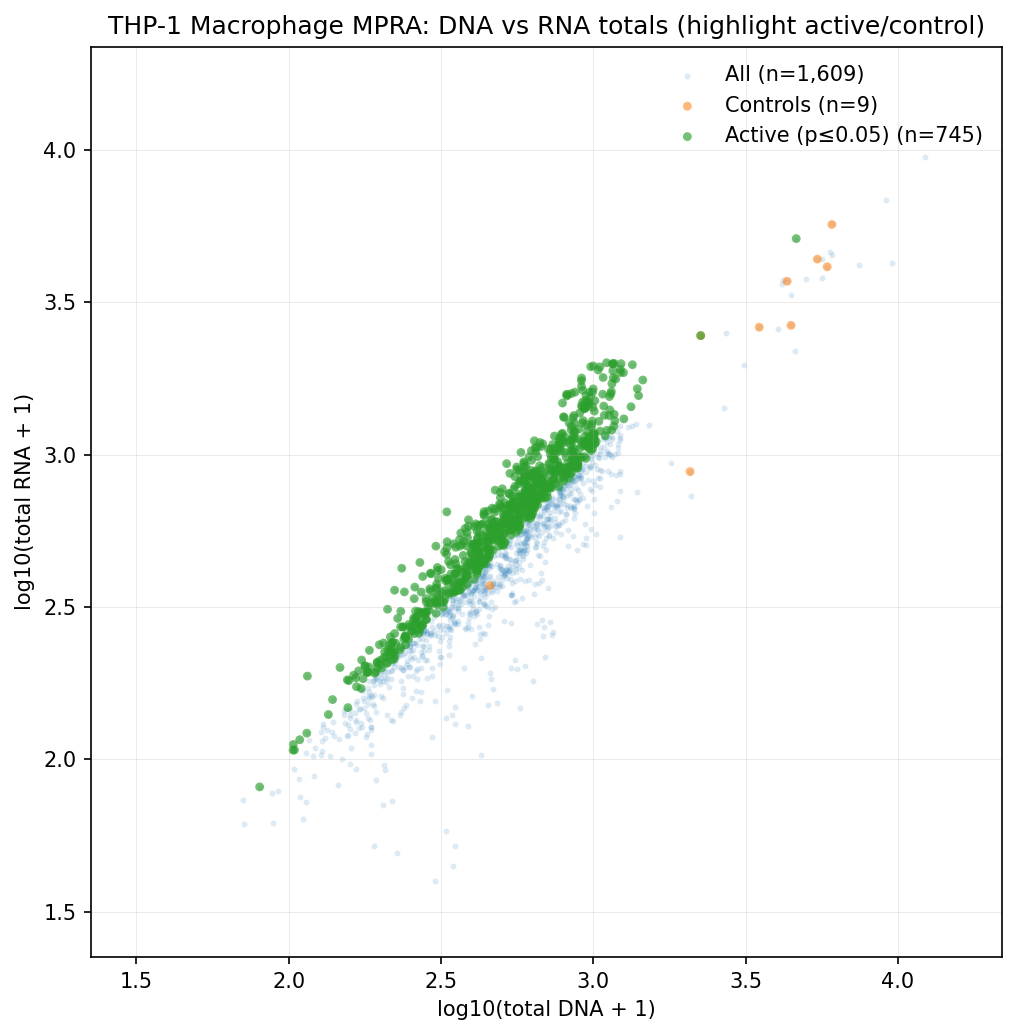

In [6]:
# %% [markdown]
# # DNA vs RNA total counts (log10) with active/control highlights

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# %%
dna_path = "../outputs/read_counts_R1R2/THP1Macrophage_DNA_matched_barcodes_reshaped_altref_withcontrol_noSV40.csv"
rna_path = "../outputs/read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref_withcontrol_noSV40.csv"
mad_path = "../outputs/mpranalyze_results/20260120_MAD_THP1Macrophage_noSV40.csv"

special_id = "PanTissueControl.SV40_224bp_1xEnh_Promoter"

# %%
# Load and compute per-element total DNA/RNA (sum across barcode columns)
dna = pd.read_csv(dna_path, index_col=0).sum(axis=1)
rna = pd.read_csv(rna_path, index_col=0).sum(axis=1)
dna=dna/dna.sum()*1000000
rna=rna/rna.sum()*1000000
mad = pd.read_csv(mad_path, index_col=0)

threshold = 0.05
# %%
# Indices
active_index = mad.index[mad["pval.empirical"] <= threshold]
control_index = mad.index[mad["control"] == True]

# Make sure indices exist in dna/rna tables (avoid KeyError)
common = dna.index.intersection(rna.index)
active_index = common.intersection(active_index)
control_index = common.intersection(control_index)

# %%
# log transform (add pseudocount to avoid log(0))
x = np.log10(dna.loc[common] + 1)
y = np.log10(rna.loc[common] + 1)

xa = np.log10(dna.loc[active_index] + 1)
ya = np.log10(rna.loc[active_index] + 1)

xc = np.log10(dna.loc[control_index] + 1)
yc = np.log10(rna.loc[control_index] + 1)

# special point (if present)
has_special = special_id in common
if has_special:
    xs = float(np.log10(dna.loc[special_id] + 1))
    ys = float(np.log10(rna.loc[special_id] + 1))

# %%
# Plot
fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

# Background: all points
ax.scatter(x, y, s=8, alpha=0.15, linewidths=0, label=f"All (n={len(common):,})")

# Controls
ax.scatter(xc, yc, s=18, alpha=0.55, linewidths=0.2, edgecolors="none", label=f"Controls (n={len(control_index):,})")

# Active
ax.scatter(xa, ya, s=18, alpha=0.65, linewidths=0.2, edgecolors="none", label=f"Active (p≤{threshold}) (n={len(active_index):,})")

# Special point
if has_special:
    ax.scatter([xs], [ys], s=80, alpha=0.95, marker="*", label="SV40 ori element")

# Reference line y = x
xmin = float(min(x.min(), y.min()))
xmax = float(max(x.max(), y.max()))
pad = 0.25
lo = xmin - pad
hi = xmax + pad
#ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

# Labels / styling
ax.set_xlabel("log10(total DNA + 1)")
ax.set_ylabel("log10(total RNA + 1)")
ax.set_title("THP-1 Macrophage MPRA: DNA vs RNA totals (highlight active/control)")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")

ax.grid(True, linewidth=0.4, alpha=0.3)
ax.legend(frameon=False, loc="best")

# Annotate special point nicely
if has_special:
    ax.annotate(
        special_id,
        xy=(xs, ys),
        xytext=(xs + 0.6, ys + 0.6),
        arrowprops=dict(arrowstyle="->", linewidth=0.8),
        fontsize=8,
    )

plt.tight_layout()
plt.show()



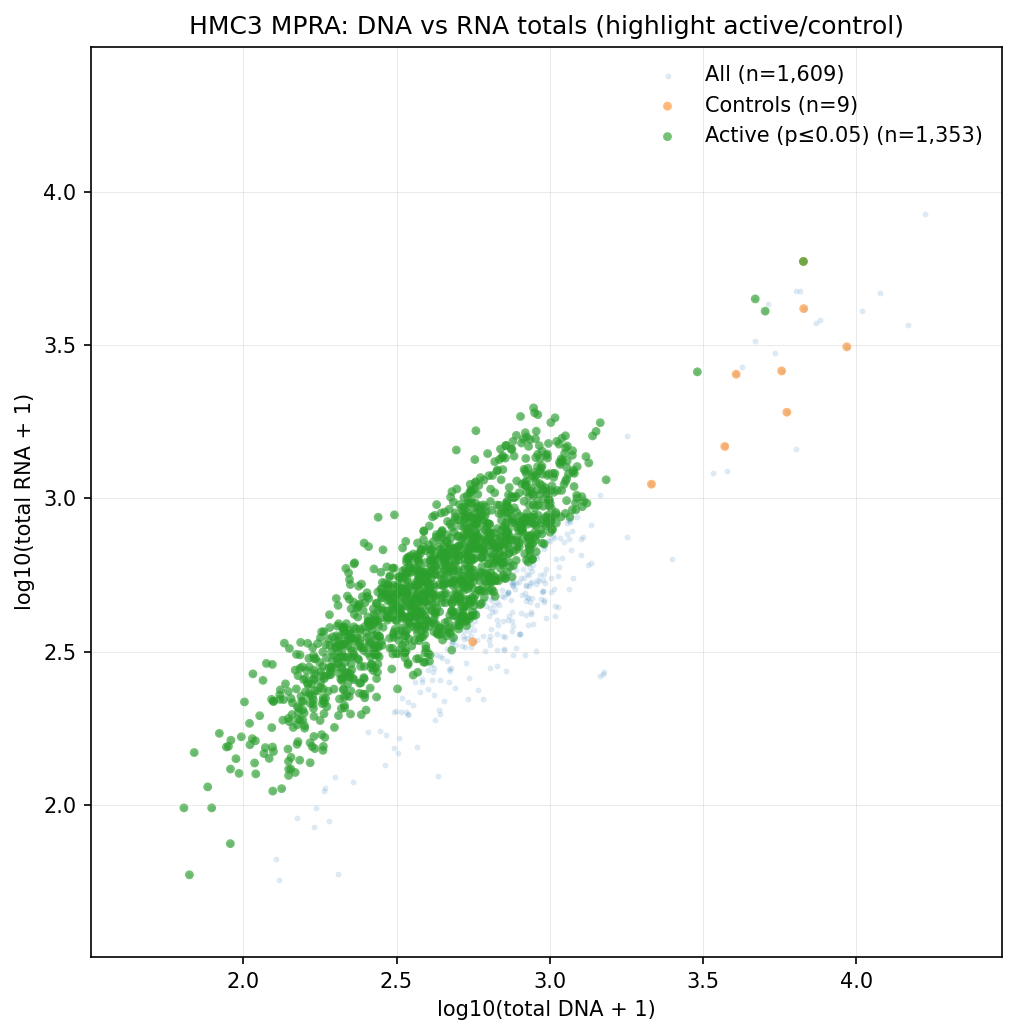

In [8]:
# %% [markdown]
# # DNA vs RNA total counts (log10) with active/control highlights

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# %%
dna_path = "../outputs/read_counts_R1R2/HMC3_DNA_matched_barcodes_reshaped_altref_withcontrol_noSV40.csv"
rna_path = "../outputs/read_counts_R1R2/HMC3_RNA_matched_barcodes_reshaped_altref_withcontrol_noSV40.csv"
mad_path = "../outputs/mpranalyze_results/20260120_MAD_HMC3_noSV40.csv"

special_id = "PanTissueControl.SV40_224bp_1xEnh_Promoter"

# %%
# Load and compute per-element total DNA/RNA (sum across barcode columns)
dna = pd.read_csv(dna_path, index_col=0).sum(axis=1)
rna = pd.read_csv(rna_path, index_col=0).sum(axis=1)
dna=dna/dna.sum()*1000000
rna=rna/rna.sum()*1000000
mad = pd.read_csv(mad_path, index_col=0)

threshold = 0.05
# %%
# Indices
active_index = mad.index[mad["pval.empirical"] <= threshold]
control_index = mad.index[mad["control"] == True]

# Make sure indices exist in dna/rna tables (avoid KeyError)
common = dna.index.intersection(rna.index)
active_index = common.intersection(active_index)
control_index = common.intersection(control_index)

# %%
# log transform (add pseudocount to avoid log(0))
x = np.log10(dna.loc[common] + 1)
y = np.log10(rna.loc[common] + 1)

xa = np.log10(dna.loc[active_index] + 1)
ya = np.log10(rna.loc[active_index] + 1)

xc = np.log10(dna.loc[control_index] + 1)
yc = np.log10(rna.loc[control_index] + 1)

# special point (if present)
has_special = special_id in common
if has_special:
    xs = float(np.log10(dna.loc[special_id] + 1))
    ys = float(np.log10(rna.loc[special_id] + 1))

# %%
# Plot
fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

# Background: all points
ax.scatter(x, y, s=8, alpha=0.15, linewidths=0, label=f"All (n={len(common):,})")

# Controls
ax.scatter(xc, yc, s=18, alpha=0.55, linewidths=0.2, edgecolors="none", label=f"Controls (n={len(control_index):,})")

# Active
ax.scatter(xa, ya, s=18, alpha=0.65, linewidths=0.2, edgecolors="none", label=f"Active (p≤{threshold}) (n={len(active_index):,})")

# Special point
if has_special:
    ax.scatter([xs], [ys], s=80, alpha=0.95, marker="*", label="SV40 ori element")

# Reference line y = x
xmin = float(min(x.min(), y.min()))
xmax = float(max(x.max(), y.max()))
pad = 0.25
lo = xmin - pad
hi = xmax + pad
#ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

# Labels / styling
ax.set_xlabel("log10(total DNA + 1)")
ax.set_ylabel("log10(total RNA + 1)")
ax.set_title("HMC3 MPRA: DNA vs RNA totals (highlight active/control)")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")

ax.grid(True, linewidth=0.4, alpha=0.3)
ax.legend(frameon=False, loc="best")

# Annotate special point nicely
if has_special:
    ax.annotate(
        special_id,
        xy=(xs, ys),
        xytext=(xs + 0.6, ys + 0.6),
        arrowprops=dict(arrowstyle="->", linewidth=0.8),
        fontsize=8,
    )

plt.tight_layout()
plt.show()



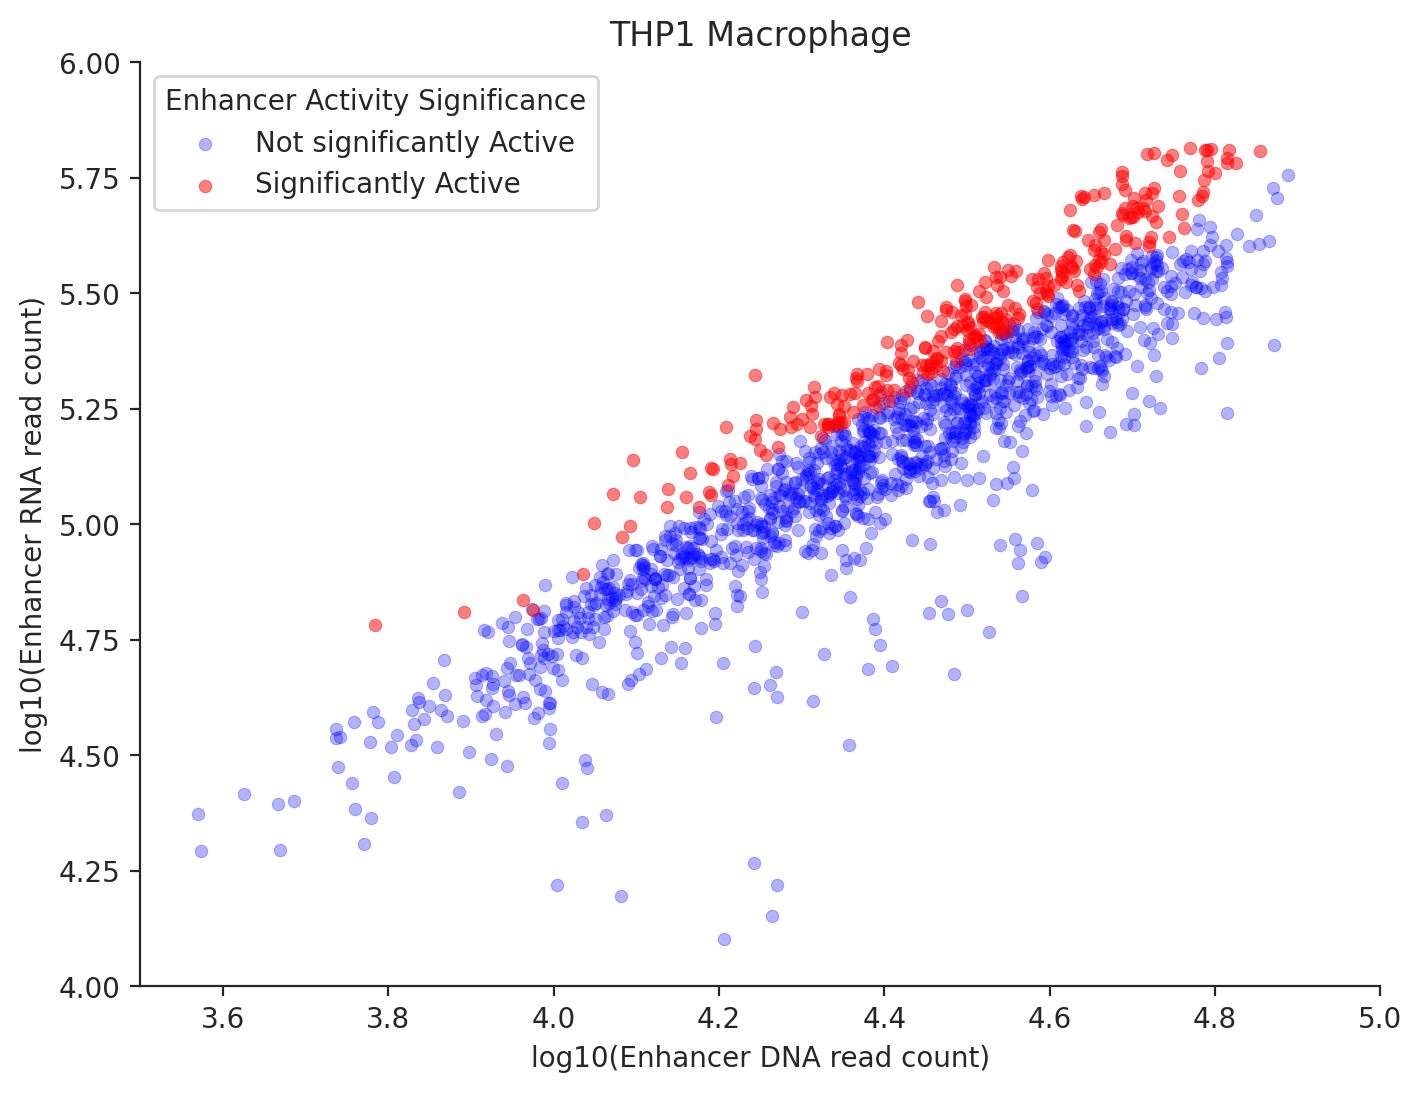

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the Seaborn style
sns.set_style('ticks')

# Read your data
df_mad = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_THP1Macrophage.csv', index_col=0)
df_mad_sig = df_mad[df_mad['pval.mad'] <= 0.1]

RNA = pd.read_csv("read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref.csv", index_col=0)
DNA = pd.read_csv("read_counts_R1R2/THP1Macrophage_DNA_matched_barcodes_reshaped_altref.csv", index_col=0)

# Sum the reads
DNA_sum = DNA.sum(axis=1)
RNA_sum = RNA.sum(axis=1)

# Create a DataFrame for plotting
data = pd.DataFrame({
    'DNA_sum_log10': np.log10(DNA_sum),
    'RNA_sum_log10': np.log10(RNA_sum)
})

# Add a 'Significance' column
data['Significance'] = 'Not significant'
data.loc[df_mad_sig.index, 'Significance'] = 'Significant'

# Separate the data into two DataFrames
data_not_sig = data[data['Significance'] == 'Not significant']
data_sig = data[data['Significance'] == 'Significant']

# Plotting
plt.figure(figsize=(8, 6), dpi=200)

# Plot non-significant points
sns.scatterplot(
    data=data_not_sig,
    x='DNA_sum_log10',
    y='RNA_sum_log10',
    color='blue',
    alpha=0.3,      # Adjusted for better visibility
    edgecolor=None,
    s=20,
    label='Not significantly Active'
)

# Plot significant points
sns.scatterplot(
    data=data_sig,
    x='DNA_sum_log10',
    y='RNA_sum_log10',
    color='red',
    alpha=0.5,      # Fully opaque
    edgecolor=None,
    s=20,
    label='Significantly Active'
)

# Improve the legend
plt.legend(title='Enhancer Activity Significance', loc='upper left')

plt.xlim(3.5,5)
plt.ylim(4,6)  

# Add titles and labels
plt.title("THP1 Macrophage")
plt.xlabel("log10(Enhancer DNA read count)")
plt.ylabel("log10(Enhancer RNA read count)")

# Remove the top and right spines
sns.despine()
plt.savefig('Mouse Brain significant REF enhancers.pdf', dpi=300, format='pdf', bbox_inches='tight')
# Show the plot
plt.show()


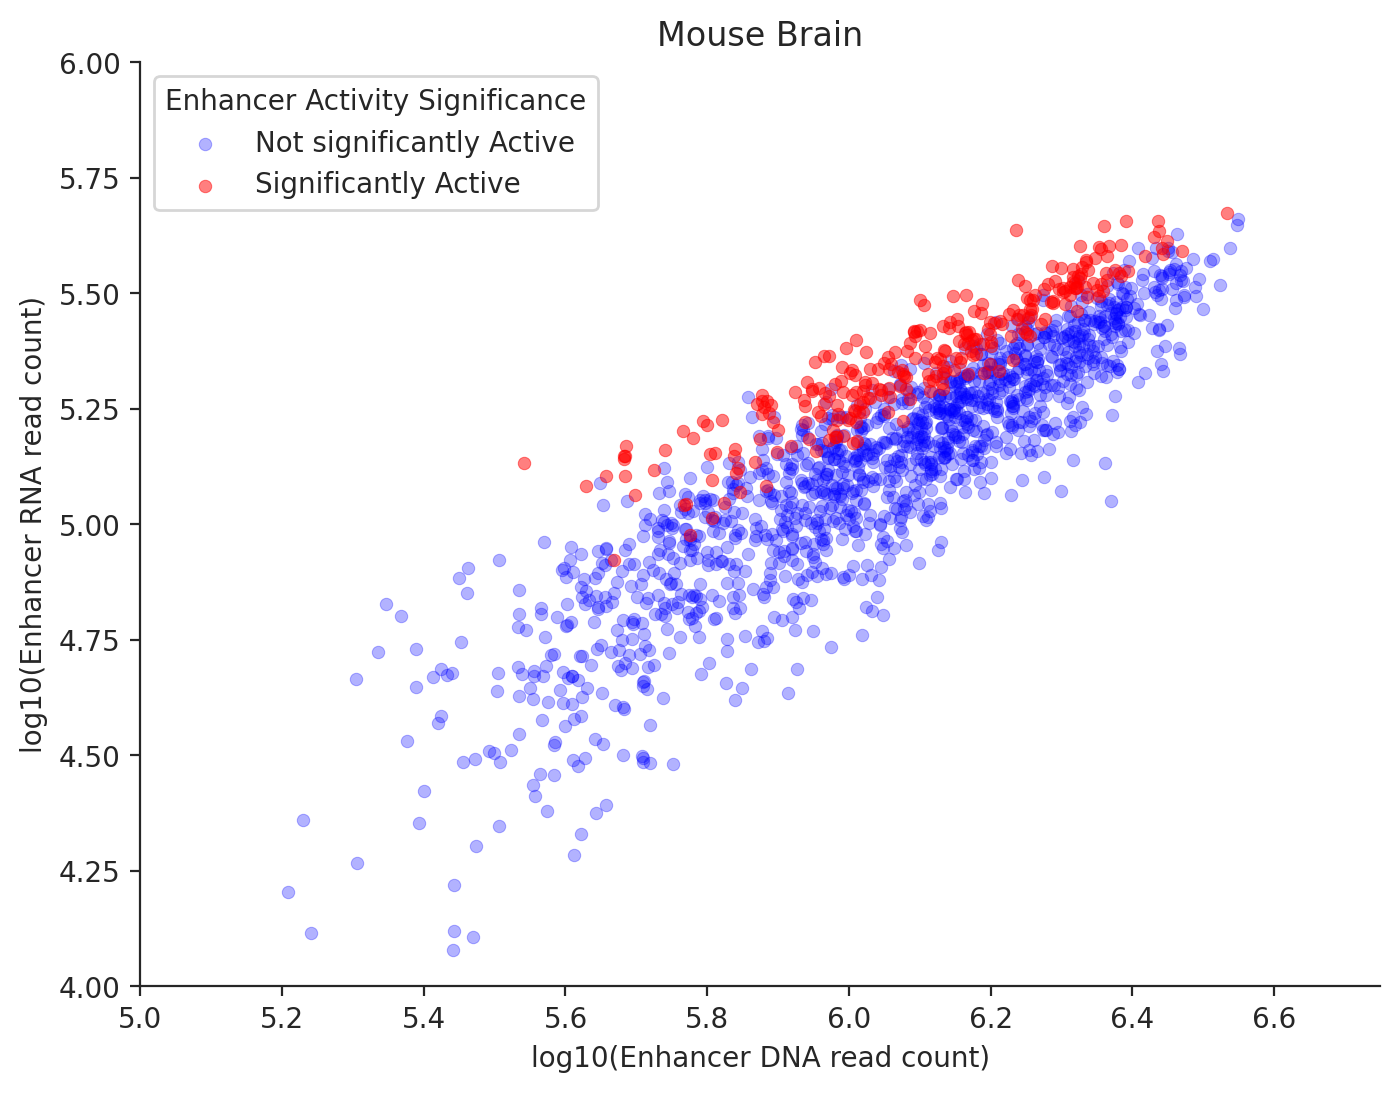

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the Seaborn style
sns.set_style('ticks')

# Read your data
df_mad = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_Brain.csv',index_col = 0)
df_mad_sig = df_mad[df_mad['pval.mad'] <= 0.1]

RNA = pd.read_csv("read_counts_R1R2/BrainR1R2merged20240404_RNA_matched_barcodes_reshaped_altref.csv",index_col=0)
DNA = pd.read_csv("read_counts_R1R2/BrainR1R2merged20240404_DNA_matched_barcodes_reshaped_altref.csv",index_col=0)

# Sum the reads
DNA_sum = DNA.sum(axis=1)
RNA_sum = RNA.sum(axis=1)

# Create a DataFrame for plotting
data = pd.DataFrame({
    'DNA_sum_log10': np.log10(DNA_sum),
    'RNA_sum_log10': np.log10(RNA_sum)
})

# Add a 'Significance' column
data['Significance'] = 'Not significant'
data.loc[df_mad_sig.index, 'Significance'] = 'Significant'

# Separate the data into two DataFrames
data_sig = data[data['Significance'] == 'Significant']
data_not_sig = data[data['Significance'] == 'Not significant']


# Plotting
plt.figure(figsize=(8, 6), dpi=200)

# Plot non-significant points
sns.scatterplot(
    data=data_not_sig,
    x='DNA_sum_log10',
    y='RNA_sum_log10',
    color='blue',
    alpha=0.3,      # Adjusted for better visibility
    edgecolor=None,
    s=20,
    label='Not significantly Active'
)

# Plot significant points
sns.scatterplot(
    data=data_sig,
    x='DNA_sum_log10',
    y='RNA_sum_log10',
    color='red',
    alpha=0.5,      # Fully opaque
    edgecolor=None,
    s=20,
    label='Significantly Active'
)

# Improve the legend
plt.legend(title='Enhancer Activity Significance', loc='upper left')

plt.xlim(5,6.75)
plt.ylim(4,6)  

# Add titles and labels
plt.title("Mouse Brain")
plt.xlabel("log10(Enhancer DNA read count)")
plt.ylabel("log10(Enhancer RNA read count)")

# Remove the top and right spines
sns.despine()
plt.savefig('Mouse Brain significant enhancers.pdf', dpi=300, format='pdf', bbox_inches='tight')
# Show the plot
plt.show()
